# E1: time-mean biases

AIMIP evaluations of time-mean biases in the train (1979-2014, in-sample) and test (2015-2024, out of sample) periods.

In [1]:
import xarray as xr
import numpy as np
import os
from dask.diagnostics import ProgressBar
from cartopy import crs as ccrs
from matplotlib import pyplot as plt

from aimip_data_utils import (
    AIMIP_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    ERA5_1DEG,
    open_aimip_data,
    add_latlon_to_dlesym,
    regrid_dataset,
    transfer_attrs,
    convert_tdas_to_huss,
    compute_time_mean,
    compute_error,
    compute_rms,
    load_gfdl_am4_from_cmip6_gcs,
    GFDL_CM4_AMIP_ZARR_TEMPLATE,
    CATEGORICAL_COLORS,
)
import matplotlib.ticker as mticker
import textwrap


In [2]:
TRAINING_DATES = ('1979-01-01', '2014-12-31')
TEST_DATES = ('2015-01-01', '2024-12-31')
LATITUDE_LIMITS = (-87.5, 87.5) # avoid regridding artifacts at the poles
OUTDIR = os.environ.get('AIMIP_FIGURES_DIR', './figures')
CACHE_DIR = os.environ.get('AIMIP_CACHE_DIR', './cached')
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
RESET_CACHE = True
RESTORE_CACHE = False

In [3]:
monthly_data, missing_files = open_aimip_data(
    AIMIP_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='Amon',
)

ACE2.1-ERA5
specific_humidity
../../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r3i1p1f1_gr_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r4i1p1f1_gr_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r5i1p1f1_gr_197810-202412.nc
surface_specific_humidity
../../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r1i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r2i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/huss/gn/v20251130/h

In [4]:
missing_files

{'ACE2.1-ERA5': ['../../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc',
  '../../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc',
  '../../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r3i1p1f1_gr_197810-202412.nc',
  '../../local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r4i1p1f1_gr_197810-202412.nc',
  '../../local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r5i1p1f1_gr_197810-202412.nc',
  '../../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/psl/gr/v20251130/psl_Amon_ACE2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc',
  '../../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/psl/gr/v20251130/psl_Amon_ACE2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc',
  '../../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/psl/gr/v20251130

In [5]:
for experiment_submission_name, dataset in monthly_data.items():
    print(f"Checking {experiment_submission_name} for huss/tdas.")
    monthly_data[experiment_submission_name] = convert_tdas_to_huss(dataset)

Checking ACE2.1-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ArchesWeather for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking ArchesWeatherGen for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking cBottle1.3 for huss/tdas.
'huss' already present in dataset.
Checking DLESyM for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking MD-1.5 v0.9 for huss/tdas.
'huss' already present in dataset.
Checking NeuralGCM for huss/tdas.
Converting 'tdas' to 'huss'.
Checking NeuralGCM-HRD for huss/tdas.
Converting 'tdas' to 'huss'.


In [6]:
# open CMIP6 GFDL CM4 data
other_variables = ['lat', 'lat_bnds', 'lon', 'lon_bnds']
gfdl_cm4_monthly_1deg, missing_paths = load_gfdl_am4_from_cmip6_gcs(
    GFDL_CM4_AMIP_ZARR_TEMPLATE,
    EVALUATION_VARIABLES,
    other_variables,
)
monthly_data['GFDL-CM4'] = gfdl_cm4_monthly_1deg.expand_dims({'realization': [1]})

gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/hus/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/huss/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/pr/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/ps/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/psl/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/ta/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/tas/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/ts/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/ua/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/uas/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/va/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/vas/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/zg/gr1/v2

In [7]:
# specific fixes

# add coordinates to DLESyM
monthly_data['DLESyM'] = add_latlon_to_dlesym(monthly_data['DLESyM'])

# ArchesWeather surface temperature has different units (C)
for experiment_submission in ['ArchesWeather', 'ArchesWeatherGen']:
    monthly_data[experiment_submission]['ts'] = monthly_data[experiment_submission].ts + 273.15

In [8]:
era5_monthly_1deg, missing_files_era5 = open_aimip_data(
    [ERA5_1DEG],
    EVALUATION_VARIABLES,
    table='Amon',
    n_realizations=1,
)
era5_monthly_1deg = (
    era5_monthly_1deg['ERA5']
    .isel(realization=0).squeeze()
    .drop_vars(['forecast_period', 'originating_centre'])
)

ERA5
specific_humidity
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_hus_1978-2024.nc
surface_specific_humidity
Not found: ../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_huss_1978-2024.nc
dew_point_temperature
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_tdas_1978-2024.nc
precipitation_flux
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_pr_1978-2024.nc
surface_air_pressure
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ps_1978-2024.nc
air_pressure_at_sea_level
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_psl_1978-2024.nc
air_temperature


/home/brianhenn/dev/AIMIP/evaluations/notebooks/aimip_data_utils.py:655: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  variable_dataset = xr.open_dataset(path, chunks={})
/home/brianhenn/dev/AIMIP/evaluations/notebooks/aimip_data_utils.py:655: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a tim

../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ta_1978-2024.nc
air_temperature
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_tas_1978-2024.nc
surface_temperature
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ts_1978-2024.nc
eastward_wind
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ua_1978-2024.nc
eastward_wind
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_uas_1978-2024.nc
northward_wind


/home/brianhenn/dev/AIMIP/evaluations/notebooks/aimip_data_utils.py:655: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  variable_dataset = xr.open_dataset(path, chunks={})
/home/brianhenn/dev/AIMIP/evaluations/notebooks/aimip_data_utils.py:655: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a tim

../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_va_1978-2024.nc
northward_wind
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_vas_1978-2024.nc
geopotential_height
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_zg_1978-2024.nc


/home/brianhenn/dev/AIMIP/evaluations/notebooks/aimip_data_utils.py:655: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  variable_dataset = xr.open_dataset(path, chunks={})


In [9]:
missing_files_era5

{'ERA5': ['../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_huss_1978-2024.nc']}

In [10]:
era5_monthly_1deg = convert_tdas_to_huss(era5_monthly_1deg)

Converting 'tdas' to 'huss'.


In [11]:
# For GFDL-CM4, propagate any-NaN cells to NaN across the full time axis
# for pressure-level variables. CM4's surface pressure varies in time →
# cells near topography are intermittently below-surface. Computing means
# or trends from a partial time series introduces small errors and makes the
# comparison domain inconsistent with ERA5. The existing downstream
# isnull().all() mask correctly handles these cells once their means are NaN.
for _var in list(monthly_data['GFDL-CM4'].data_vars):
    _da = monthly_data['GFDL-CM4'][_var]
    if 'plev' in _da.dims:
        _below_surface_any = _da.isnull().any('time')
        monthly_data['GFDL-CM4'][_var] = _da.where(~_below_surface_any)

In [12]:
with xr.set_options(keep_attrs=True):
    time_mean = {
        k: xr.concat(
            [
                compute_time_mean(v, start=TRAINING_DATES[0], end=TRAINING_DATES[1]).expand_dims({'time_period': ['training']}),
                compute_time_mean(v, start=TEST_DATES[0], end=TEST_DATES[1]).expand_dims({'time_period': ['test']}),
            ],
            dim='time_period'
        ) for k, v in monthly_data.items()
    }

In [13]:
with ProgressBar():
    time_mean = {
        k: v.compute() for k, v in time_mean.items()
    }

[########################################] | 100% Completed | 163.10 s
[########################################] | 100% Completed | 116.04 s
[########################################] | 100% Completed | 116.26 s
[########################################] | 100% Completed | 249.32 s
[########################################] | 100% Completed | 10.29 s
[########################################] | 100% Completed | 257.86 s
[########################################] | 100% Completed | 75.37 s
[########################################] | 100% Completed | 108.34 s
[########################################] | 100% Completed | 13.94 s


In [14]:
with xr.set_options(keep_attrs=True):
    time_mean_era5_1deg = xr.concat(
        [
            compute_time_mean(era5_monthly_1deg, start=TRAINING_DATES[0], end=TRAINING_DATES[1]).expand_dims({'time_period': ['training']}),
            compute_time_mean(era5_monthly_1deg, start=TEST_DATES[0], end=TEST_DATES[1]).expand_dims({'time_period': ['test']}),
        ],
        dim='time_period'
    )

In [15]:
with ProgressBar():
    time_mean_era5_1deg = time_mean_era5_1deg.compute()

[########################################] | 100% Completed | 99.90 s


In [16]:
regridded_1deg_time_means = []
experiment_submissions_1deg = list(time_mean.keys())
experiment_submissions_1deg.remove('NeuralGCM') # don't evaluate 2.8 deg at 1 deg
for experiment_submission_name in experiment_submissions_1deg:
    print(experiment_submission_name)
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
    else: 
        # for HEALPix grid, need to use nearest-neighbor unstructured interpolation
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
    # destination grid is 1deg ERA5
    destination_grid = (
        time_mean_era5_1deg
        .isel(time_period=0)
        .sel(lat=slice(*LATITUDE_LIMITS))
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )
    regridded_1deg_time_mean = regrid_dataset(
        time_mean[experiment_submission_name],
        destination_grid,
        sample_dims=['realization', 'time_period'],
        **regridder_kwargs
    )
    regridded_1deg_time_means.append(
        regridded_1deg_time_mean.expand_dims(
            {
                'experiment_submission': [experiment_submission_name]
            }
        )
    )
regridded_1deg_time_means = xr.concat(
    regridded_1deg_time_means,
    dim='experiment_submission',
    join='outer',
    combine_attrs='override',
    coords='minimal',
)
# Mask ERA5 pressure-level data to AM4's valid (above-surface) domain.
# AM4 leaves below-surface grid cells as NaN; ERA5 artificially infills them.
# Masking ERA5 here ensures all downstream computations (eg global
# means) are over the same physical domain as AM4, making metrics comparable.
_am4_1deg = regridded_1deg_time_means.sel(experiment_submission='GFDL-CM4', drop=True)
for _var in time_mean_era5_1deg.data_vars:
    if _var in _am4_1deg.data_vars and 'plev' in time_mean_era5_1deg[_var].dims:
        _non_spatial = [d for d in _am4_1deg[_var].dims if d not in ('lat', 'lon', 'plev')]
        _below_surface = _am4_1deg[_var].isnull().all(_non_spatial)
        time_mean_era5_1deg[_var] = time_mean_era5_1deg[_var].where(~_below_surface)

ACE2.1-ERA5
ArchesWeather


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


ArchesWeatherGen


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


cBottle1.3
DLESyM
MD-1.5 v0.9
NeuralGCM-HRD


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages

GFDL-CM4


In [17]:
regridded_2p8deg_time_means = []
experiment_submissions_2p8deg = list(time_mean.keys())
experiment_submissions_2p8deg.remove('NeuralGCM-HRD') # don't evaluate 1 deg at 2.8 deg
for experiment_submission_name in experiment_submissions_2p8deg:
    print(experiment_submission_name)
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
    else: 
        # for cBottle HEALPix grid, need to use nearest-neighbor unstructured interpolation
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
    # destination grid is 2.8 deg NeuralGCM
    destination_grid = (
        time_mean['NeuralGCM']
        .isel(time_period=0, realization=0)
        .sel(lat=slice(*LATITUDE_LIMITS))
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )
    regridded_2p8deg_time_mean = regrid_dataset(
        time_mean[experiment_submission_name],
        destination_grid,
        sample_dims=['realization', 'time_period'],
        **regridder_kwargs
    )
    regridded_2p8deg_time_means.append(
        regridded_2p8deg_time_mean.expand_dims(
            {
                'experiment_submission': [experiment_submission_name]
            }
        )
    )
regridded_2p8deg_time_means = xr.concat(
    regridded_2p8deg_time_means,
    dim='experiment_submission',
    join='outer',
    combine_attrs='override',
    coords='minimal',
)

ACE2.1-ERA5
ArchesWeather


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


ArchesWeatherGen


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


cBottle1.3
DLESyM
MD-1.5 v0.9
NeuralGCM


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages

GFDL-CM4


In [18]:
# regrid ERA5 to 2.8 deg NeuralGCM grid
destination_grid_era5 = (
    time_mean['NeuralGCM']
    .isel(time_period=0, realization=0)
    .sel(lat=slice(*LATITUDE_LIMITS))
    [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
)
regridded_2p8deg_time_mean_era5 = regrid_dataset(
    time_mean_era5_1deg,
    destination_grid_era5,
    sample_dims=['time_period'],
    method='conservative',
)

In [19]:
if RESET_CACHE:
    path_1deg = os.path.join(CACHE_DIR, 'regridded_1deg_time_means.nc')
    path_1deg_era5 = os.path.join(CACHE_DIR, 'time_mean_era5_1deg.nc')
    path_2p8deg = os.path.join(CACHE_DIR, 'regridded_2p8deg_time_means.nc')
    path_2p8deg_era5 = os.path.join(CACHE_DIR, 'regridded_2p8deg_time_mean_era5.nc')
    try:
        os.remove(path_1deg)
        os.remove(path_1deg_era5)
        os.remove(path_2p8deg)
        os.remove(path_2p8deg_era5)
    except FileNotFoundError:
        print("Nothing deleted from cache.")
    regridded_1deg_time_means.to_netcdf(path_1deg)
    time_mean_era5_1deg.to_netcdf(path_1deg_era5)
    regridded_2p8deg_time_means.to_netcdf(path_2p8deg)
    regridded_2p8deg_time_mean_era5.to_netcdf(path_2p8deg_era5)
    print("Cache updated.")

Cache updated.


In [3]:
if RESTORE_CACHE: 
    print("Cache restored.")
    path_1deg = os.path.join(CACHE_DIR, 'regridded_1deg_time_means.nc')
    path_1deg_era5 = os.path.join(CACHE_DIR, 'time_mean_era5_1deg.nc')
    path_2p8deg = os.path.join(CACHE_DIR, 'regridded_2p8deg_time_means.nc')
    path_2p8deg_era5 = os.path.join(CACHE_DIR, 'regridded_2p8deg_time_mean_era5.nc')
    regridded_1deg_time_means = xr.open_dataset(path_1deg)
    time_mean_era5_1deg = xr.open_dataset(path_1deg_era5)
    regridded_2p8deg_time_means = xr.open_dataset(path_2p8deg)
    regridded_2p8deg_time_mean_era5 = xr.open_dataset(path_2p8deg_era5)

Cache restored.


In [4]:
biases_1deg = compute_error(
    regridded_1deg_time_means,
    time_mean_era5_1deg,
)
exp_names = [exp.item() for exp in biases_1deg.experiment_submission]
exp_names.remove('GFDL-CM4')
sorted_exp_names = sorted(exp_names, key=lambda x: x.lower()) + ['GFDL-CM4']
biases_1deg = biases_1deg.sel(experiment_submission=sorted_exp_names)

In [5]:
biases_2p8deg = compute_error(
    regridded_2p8deg_time_means,
    regridded_2p8deg_time_mean_era5,
)
exp_names = [exp.item() for exp in biases_2p8deg.experiment_submission]
exp_names.remove('GFDL-CM4')
sorted_exp_names = sorted(exp_names, key=lambda x: x.lower()) + ['GFDL-CM4']
biases_2p8deg = biases_2p8deg.sel(experiment_submission=sorted_exp_names)

In [6]:
rmsb_1deg = compute_rms(biases_1deg)
rmsb_2p8deg = compute_rms(biases_2p8deg)

In [7]:
def get_varname_indexer(var: str) -> tuple[str, dict[str, float]]:
    if var in ['tas', 'ts', 'pr', 'huss']:
        return var, {}
    elif var.startswith('Q'):
        return 'hus', {'plev': [85000.]}
    elif var.startswith('U'):
        return 'ua', {'plev': [85000.]}
    elif var.startswith('V'):
        return 'va', {'plev': [85000.]}
    elif var.startswith('AT'):
        if var.endswith('100'):
            return 'ta', {'plev': [10000.]}
        else:
            return 'ta', {'plev': [85000.]}
      
map_vars = ['tas', 'ts', 'pr', 'huss', 'AT850', 'AT100', 'Q850', 'U850', 'V850']

In [ ]:
time_period='test'
for var in map_vars:
    print(var)
    varname, indexer = get_varname_indexer(var)
    plottable = biases_1deg.drop_sel(experiment_submission='GFDL-CM4').sel(time_period=time_period, **indexer)[varname]
    vmin = plottable.median('realization').quantile(0.02)
    fg = plottable.plot(
        col='experiment_submission', row='realization', cmap='RdBu_r', vmin=vmin, vmax=-vmin,
        subplot_kws=dict(projection=ccrs.Robinson()),
        transform=ccrs.PlateCarree(),
        figsize=(16, 8),
        cbar_kwargs=dict(
            label=(
                f'{biases_1deg[varname].attrs.get("long_name", varname)} '
                f'time-mean bias [{biases_1deg[varname].attrs.get("units", "-")}]'
            ),
            orientation='horizontal',
            aspect=50
        ),
    )
    fg.set_titles('{value}')
    fg.fig.patch.set_alpha(0.0)
    fg.fig.savefig(os.path.join(OUTDIR, f'bias_1deg_map_{time_period}_{var}.png'), bbox_inches='tight')

In [ ]:
time_period='training'
for var in map_vars:
    print(var)
    varname, indexer = get_varname_indexer(var)
    plottable = biases_1deg.sel(time_period=time_period, **indexer)[varname]
    vmin = plottable.median('realization').quantile(0.02)
    fg = plottable.plot(
        col='experiment_submission', row='realization', cmap='RdBu_r', vmin=vmin, vmax=-vmin,
        subplot_kws=dict(projection=ccrs.Robinson()),
        transform=ccrs.PlateCarree(),
        figsize=(16, 8),
        cbar_kwargs=dict(
            label=(
                f'{biases_1deg[varname].attrs.get("long_name", varname)} '
                f'time-mean bias [{biases_1deg[varname].attrs.get("units", "-")}]'
            ),
            orientation='horizontal',
            aspect=50
        ),
    )
    fg.set_titles('{value}')
    fg.fig.patch.set_alpha(0.0)
    fg.fig.savefig(os.path.join(OUTDIR, f'bias_1deg_map_{time_period}_{var}.png'), bbox_inches='tight')

In [ ]:
time_period = 'test'
for var in map_vars:
    print(var)
    varname, indexer = get_varname_indexer(var)
    plottable = biases_2p8deg.drop_sel(experiment_submission='GFDL-CM4').sel(time_period=time_period, **indexer)[varname]
    vmin = plottable.median('realization').quantile(0.02)
    fg = plottable.plot(
        col='experiment_submission', row='realization', cmap='RdBu_r', vmin=vmin, vmax=-vmin,
        subplot_kws=dict(projection=ccrs.Robinson()),
        transform=ccrs.PlateCarree(),
        figsize=(16, 8),
        cbar_kwargs=dict(
            label=(
                f'{biases_2p8deg[varname].attrs.get("long_name", varname)} '
                f'time-mean bias [{biases_2p8deg[varname].attrs.get("units", "-")}]'
            ),
            orientation='horizontal',
            aspect=50,
        ),
    )
    fg.set_titles('{value}')
    fg.fig.patch.set_alpha(0.0)
    fg.fig.savefig(os.path.join(OUTDIR, f'bias_2p8deg_map_{time_period}_{var}.png'), bbox_inches='tight')

In [ ]:
for varname in [varname for varname in rmsb_1deg.data_vars if "plev" in rmsb_1deg[varname].dims]:
    fig, ax = plt.subplots(figsize=(12, 5))
    rmsb_1deg_var = rmsb_1deg[varname].rename('RMSB').transpose('time_period', 'plev', 'experiment_submission', 'realization')
    lowest, median, highest = (
        rmsb_1deg_var.min('realization').to_dataframe().unstack(),
        rmsb_1deg_var.median('realization').to_dataframe().unstack(),
        rmsb_1deg_var.max('realization').to_dataframe().unstack(),
    )
    median.plot.bar(width=0.9, 
        ax=ax,
        legend=False,
        color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values.T[:, None, :], (highest - median).values.T[:, None, :]], axis=1),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    ax.legend(rmsb_1deg.experiment_submission.values, fontsize='small')
    ymax = median.max().mean()
    ax.set_ylim([0, ymax])
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    ax.fill_between([(xlim[0] + xlim[1]) / 2, xlim[1]], [0, 0], [ylim[1], ylim[1]], color='k', alpha=0.15, zorder=-1)
    ax.set_xticklabels([str(round(ind[1]/100)) for ind in median.index])
    ax.set_xlabel('pressure level [hPa]')
    ax.set_ylabel(f"{rmsb_1deg[varname].attrs.get('long_name', varname)} RMSB [{rmsb_1deg[varname].attrs.get('units', '-')}]")
    ax.grid(axis='y')
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"bias_1deg_RMS_{varname}.png"), bbox_inches='tight')

In [ ]:
surface_vars = [var for var in rmsb_1deg.data_vars if "plev" not in rmsb_1deg[var].coords]
fig, axes = plt.subplots(ncols=int(np.ceil(len(surface_vars) / 2)), nrows=2, figsize=(12, 6), sharex=True, sharey=False, gridspec_kw={'wspace': 0.55, 'hspace': 0.5})
for ax, varname in zip(axes.flatten(), surface_vars):
    rsmb_1deg_var = rmsb_1deg[varname].transpose('time_period', 'experiment_submission', 'realization')
    lowest, median, highest = (
        rsmb_1deg_var.min('realization').to_dataframe().unstack(),
        rsmb_1deg_var.median('realization').to_dataframe().unstack(),
        rsmb_1deg_var.max('realization').to_dataframe().unstack(),
    )
    median.plot.bar(width=0.9, 
        ax=ax,
        legend=False,
        color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values.T[:, None, :], (highest - median).values.T[:, None, :]], axis=1),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    if ax is axes.flatten()[-2]:
        axes.flatten()[-1].set_axis_off()
        ax.legend(rmsb_1deg.experiment_submission.values, fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
    ymax = median.max().max()
    ax.set_ylim([0, ymax])
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    ax.fill_between([(xlim[0] + xlim[1]) / 2, xlim[1]], [0, 0], [ylim[1], ylim[1]], color='k', alpha=0.15, zorder=-1)
    ax.set_xticklabels([ind for ind in median.index])
    ax.set_xlabel('')
    ax.set_ylabel(f"{rmsb_1deg[varname].attrs.get('long_name', varname)} RMSB [{rmsb_1deg[varname].attrs.get('units', '-')}]")
    ax.grid(axis='y')
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, "bias_1deg_RMS_surface_variables.png"), bbox_inches='tight')

In [ ]:
for varname in [varname for varname in rmsb_2p8deg.data_vars if "plev" in rmsb_2p8deg[varname].dims]:
    fig, ax = plt.subplots(figsize=(12, 5))
    rmsb_2p8deg_var = rmsb_2p8deg[varname].rename('RMSB').transpose('time_period', 'plev', 'experiment_submission', 'realization')
    lowest, median, highest = (
        rmsb_2p8deg_var.min('realization').to_dataframe().unstack(),
        rmsb_2p8deg_var.median('realization').to_dataframe().unstack(),
        rmsb_2p8deg_var.max('realization').to_dataframe().unstack(),
    )
    median.plot.bar(width=0.9, 
        ax=ax,
        legend=False,
        color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values.T[:, None, :], (highest - median).values.T[:, None, :]], axis=1),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    ax.legend(rmsb_2p8deg.experiment_submission.values, fontsize='small')
    ymax = median.max().mean()
    ax.set_ylim([0, ymax])
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    ax.fill_between([(xlim[0] + xlim[1]) / 2, xlim[1]], [0, 0], [ylim[1], ylim[1]], color='k', alpha=0.15, zorder=-1)
    ax.set_xticklabels([str(round(ind[1]/100)) for ind in median.index])
    ax.set_xlabel('pressure level [hPa]')
    ax.set_ylabel(f"{rmsb_2p8deg[varname].attrs.get('long_name', varname)} RMSB [{rmsb_2p8deg[varname].attrs.get('units', '-')}]")
    ax.grid(axis='y')
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"bias_2p8deg_RMS_{varname}.png"), bbox_inches='tight')

In [ ]:
surface_vars = [var for var in rmsb_2p8deg.data_vars if "plev" not in rmsb_2p8deg[var].coords]
fig, axes = plt.subplots(ncols=int(np.ceil(len(surface_vars) / 2)), nrows=2, figsize=(12, 6), sharex=True, sharey=False, gridspec_kw={'wspace': 0.55, 'hspace': 0.5})
for ax, varname in zip(axes.flatten(), surface_vars):
    rsmb_2p8deg_var = rmsb_2p8deg[varname].transpose('time_period', 'experiment_submission', 'realization')
    lowest, median, highest = (
        rsmb_2p8deg_var.min('realization').to_dataframe().unstack(),
        rsmb_2p8deg_var.median('realization').to_dataframe().unstack(),
        rsmb_2p8deg_var.max('realization').to_dataframe().unstack(),
    )
    median.plot.bar(width=0.9, 
        ax=ax,
        legend=False,
        color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values.T[:, None, :], (highest - median).values.T[:, None, :]], axis=1),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    if ax is axes.flatten()[-2]:
        axes.flatten()[-1].set_axis_off()
        ax.legend(rmsb_2p8deg.experiment_submission.values, fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
    ymax = median.max().max()
    ax.set_ylim([0, ymax])
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    ax.fill_between([(xlim[0] + xlim[1]) / 2, xlim[1]], [0, 0], [ylim[1], ylim[1]], color='k', alpha=0.15, zorder=-1)
    ax.set_xticklabels([ind for ind in median.index])
    ax.set_xlabel('')
    ax.set_ylabel(f"{rmsb_2p8deg[varname].attrs.get('long_name', varname)} RMSB [{rmsb_2p8deg[varname].attrs.get('units', '-')}]")
    ax.grid(axis='y')
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, "bias_2p8deg_RMS_surface_variables.png"), bbox_inches='tight')

## Manuscript Figures

In [8]:
MANUSCRIPT_DIR = os.path.join(OUTDIR, 'manuscript_figures')
os.makedirs(MANUSCRIPT_DIR, exist_ok=True)

MANUSCRIPT_DPI = 300
MANUSCRIPT_FORMAT = 'eps'

# GMD / EGU figure width limits (in inches)
GMD_SINGLE_COL_IN = 84 / 25.4   # 84 mm
GMD_DOUBLE_COL_IN = 174 / 25.4  # 174 mm
GMD_MAX_HEIGHT_IN = 170 / 25.4  # 170 mm — leave room for caption

def ms_savefig(fig, name):
    """Save a manuscript figure with consistent settings."""
    path = os.path.join(MANUSCRIPT_DIR, f'{name}.{MANUSCRIPT_FORMAT}')
    fig.savefig(path, dpi=MANUSCRIPT_DPI, format=MANUSCRIPT_FORMAT)
    print(f'Saved {path}')


Saved ./figures/manuscript_figures/bias_1deg_map_tas_pr.eps


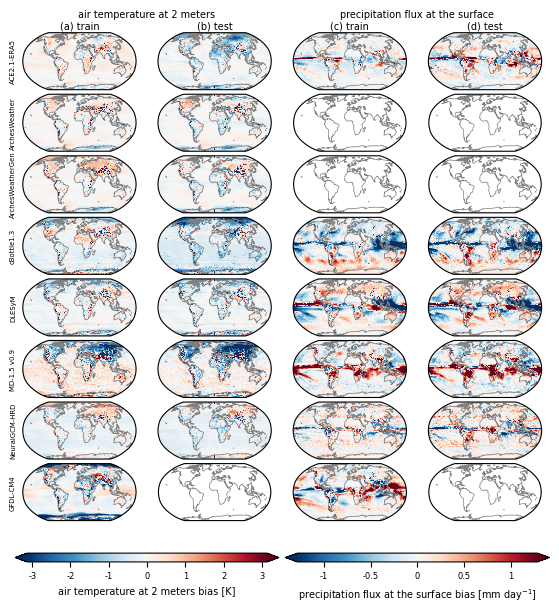

In [9]:
# Manuscript Figure 1: tas and pr time-mean biases, all models, train + test
# Layout: rows = models, columns = (tas-train, tas-test, pr-train, pr-test)

vars_to_plot = ['tas', 'pr']
time_periods  = ['training', 'test']
exp_names     = list(biases_1deg.experiment_submission.values)
n_exp         = len(exp_names)

LABEL_FS = 7

VAR_SCALE        = {'pr': 86400.}
VAR_DISPLAY_UNITS = {'pr': 'mm day$^{-1}$'}

# Columns: tas-train, tas-test, pr-train, pr-test
cols   = [(var, tp) for var in vars_to_plot for tp in time_periods]
n_cols = len(cols)
n_rows = n_exp

vlims = {
    var: float(abs(biases_1deg[var].isel(realization=0).quantile(0.02))) * VAR_SCALE.get(var, 1.0)
    for var in vars_to_plot
}

map_h      = (GMD_DOUBLE_COL_IN / n_cols) / 1.9
fig_width  = GMD_DOUBLE_COL_IN
fig_height = min(n_rows * map_h * 1.15 + 1.0, GMD_MAX_HEIGHT_IN)

fig = plt.figure(figsize=(fig_width, fig_height))
gs  = fig.add_gridspec(nrows=n_rows, ncols=n_cols, hspace=0.08, wspace=0.05)
fig.subplots_adjust(top=0.92, left=0.12)

ims_by_var   = {}
axes_by_var  = {var: [] for var in vars_to_plot}
top_row_axes = {}   # col -> ax (row 0 only), for group headers
col0_axes    = {}   # row -> ax (col 0 only), for row labels added after layout

for row, exp in enumerate(exp_names):
    for col, (var, tp) in enumerate(cols):
        scale = VAR_SCALE.get(var, 1.0)
        ax = fig.add_subplot(gs[row, col], projection=ccrs.Robinson())
        axes_by_var[var].append(ax)
        if row == 0:
            top_row_axes[col] = ax
        if col == 0:
            col0_axes[row] = ax

        data = (biases_1deg[var].isel(realization=0)
                .sel(time_period=tp, experiment_submission=exp) * scale)

        if bool(np.isnan(data.values).all()):
            ax.set_global()
        else:
            im = data.plot(
                ax=ax,
                transform=ccrs.PlateCarree(),
                cmap='RdBu_r',
                vmin=-vlims[var], vmax=vlims[var],
                add_colorbar=False,
                add_labels=False, rasterized=True,
            )
            ims_by_var[var] = im

        ax.set_title('')
        ax.coastlines(color='gray', linewidth=0.5)

        # Per-column title (first row only): short "(a) train" label.
        # Full variable name goes in group header added later via fig.text().
        if row == 0:
            period_label = 'train' if tp == 'training' else 'test'
            letter = chr(ord('a') + col)
            ax.set_title(f'({letter}) {period_label}', fontsize=LABEL_FS, pad=3)

# Colorbars — add before canvas.draw() so their effect on axes size is included
for var in vars_to_plot:
    if var not in ims_by_var:
        continue
    units     = VAR_DISPLAY_UNITS.get(var, biases_1deg[var].attrs.get('units', '-'))
    long_name = biases_1deg[var].attrs.get('long_name', var).replace('_', ' ').lower()
    cbar = fig.colorbar(
        ims_by_var[var],
        ax=axes_by_var[var],
        orientation='horizontal',
        fraction=0.04,
        pad=0.06,
        aspect=30,
        extend='both',
    )
    cbar.set_label(f'{long_name} bias [{units}]', size=LABEL_FS)
    cbar.ax.tick_params(labelsize=LABEL_FS - 1)
    cbar.ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))

# Force layout so axis positions are accurate
fig.canvas.draw()

# Row labels: compute max font size that fits within row height (avoids overprinting)
pos_r0 = col0_axes[0].get_position()
pos_r1 = col0_axes[1].get_position()
# Find largest single font size where the longest label fits within the row pitch.
# Uses actual text measurement via the renderer — no char-width guessing.
renderer = fig.canvas.get_renderer()
longest_name = max(exp_names, key=len)
row_pitch_px = (pos_r0.y0 - pos_r1.y0) * fig.get_size_inches()[1] * renderer.dpi

row_label_fs = 4  # minimum fallback
for candidate_fs in range(LABEL_FS + 2, 3, -1):
    t = col0_axes[0].text(0, -1, longest_name, fontsize=candidate_fs,
                           transform=col0_axes[0].transAxes)
    fig.canvas.draw()
    bb = t.get_window_extent(renderer=renderer)
    t.remove()
    if bb.width <= row_pitch_px * 1.15:  # allow slight overflow into row gap
        row_label_fs = candidate_fs
        break

for row, exp in enumerate(exp_names):
    col0_axes[row].text(-0.06, 0.5, exp,
                        transform=col0_axes[row].transAxes,
                        rotation=90, va='center', ha='right',
                        fontsize=row_label_fs, clip_on=False)

# Variable group headers: centered above each variable's two-column span
for vi, var in enumerate(vars_to_plot):
    pos_l = top_row_axes[vi * 2].get_position()
    pos_r = top_row_axes[vi * 2 + 1].get_position()
    x_center = (pos_l.x0 + pos_r.x1) / 2
    long_name = biases_1deg[var].attrs.get('long_name', var).replace('_', ' ').lower()
    fig.text(x_center, pos_l.y1 + 0.02, long_name,
             ha='center', va='bottom', fontsize=LABEL_FS, )

fig.patch.set_alpha(0.0)
ms_savefig(fig, 'bias_1deg_map_tas_pr')
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved ./figures/manuscript_figures/rmsb_1deg_bar_surface_and_plev.eps


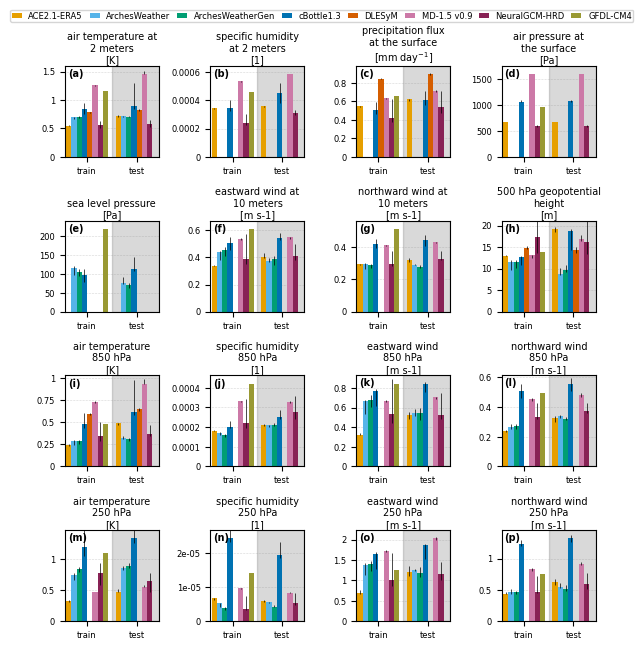

In [10]:
# Manuscript Figure 2: RMSB bar chart — surface vars (rows 1-2), 850 hPa (row 3), 250 hPa (row 4)
# Note: 200 hPa is not in the evaluation pressure levels; 250 hPa is used instead.

LABEL_FS = 7

VAR_SCALE = {
    'pr': 86400.,
}
VAR_DISPLAY_UNITS = {
    'pr': 'mm day$^{-1}$',
}

# Exact 4-row × 4-col grid layout; legend placed outside via fig.legend().
GRID = [
    [('tas', None),  ('huss', None), ('pr', None),   ('ps', None)  ],  # surface row 1
    [('psl', None),  ('uas', None),  ('vas', None),  ('zg', None)  ],  # surface row 2
    [('ta', 85000.), ('hus', 85000.),('ua', 85000.), ('va', 85000.)],  # 850 hPa
    [('ta', 25000.), ('hus', 25000.),('ua', 25000.), ('va', 25000.)],  # 250 hPa
]
NROWS, NCOLS = len(GRID), len(GRID[0])

fig_width  = GMD_DOUBLE_COL_IN
fig_height = min(NROWS * 1.8 + 0.4, GMD_MAX_HEIGHT_IN)
fig, axes  = plt.subplots(
    nrows=NROWS, ncols=NCOLS,
    figsize=(fig_width, fig_height),
    gridspec_kw={'wspace': 0.55, 'hspace': 0.7},
)
fig.subplots_adjust(top=0.90, bottom=0.07)

legend_handles = None
panel_letter = ord('a')

_tick_fmt = mticker.FuncFormatter(lambda x, _: f'{x:g}')

for r, row in enumerate(GRID):
    for c, spec in enumerate(row):
        ax = axes[r, c]

        # ── empty panel ───────────────────────────────────────────────────────
        if spec is None:
            ax.set_axis_off()
            continue

        # ── data panel ───────────────────────────────────────────────────────
        letter = chr(panel_letter)
        panel_letter += 1

        varname, plev = spec

        if varname not in rmsb_1deg:
            ax.set_axis_off()
            ax.text(0.5, 0.5, f'{varname}\nnot available',
                    transform=ax.transAxes, ha='center', va='center', fontsize=LABEL_FS - 1)
            continue

        if plev is not None:
            da = rmsb_1deg[varname].sel(plev=plev).drop_vars('plev')
        else:
            da = rmsb_1deg[varname]

        da = da.transpose('time_period', 'experiment_submission', 'realization')

        scale = VAR_SCALE.get(varname, 1.0)
        units = VAR_DISPLAY_UNITS.get(varname, rmsb_1deg[varname].attrs.get('units', '-'))
        lowest  = da.min('realization').to_dataframe().unstack() * scale
        median  = da.median('realization').to_dataframe().unstack() * scale
        highest = da.max('realization').to_dataframe().unstack() * scale

        bars = median.plot.bar(width=0.85, 
            ax=ax,
            legend=False,
            color=CATEGORICAL_COLORS,
            yerr=np.concat(
                [(median - lowest).values.T[:, None, :],
                 (highest - median).values.T[:, None, :]],
                axis=1,
            ),
            capsize=0,
            error_kw=dict(elinewidth=0.5),
        )
        if legend_handles is None:
            legend_handles, _ = ax.get_legend_handles_labels()

        ymax = median.max().max()
        ax.set_ylim([0, ymax * 1.1])
        ax.set_xlim(-0.45, 1.45)
        xlim, ylim = ax.get_xlim(), ax.get_ylim()
        mid = (xlim[0] + xlim[1]) / 2
        ax.fill_between(
            [mid, xlim[1]], [0, 0], [ylim[1], ylim[1]],
            color='k', alpha=0.15, zorder=-1,
        )
        ax.set_xticklabels(['train', 'test'], rotation=0, fontsize=LABEL_FS - 1)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.yaxis.set_major_formatter(_tick_fmt)
        ax.tick_params(axis='y', labelsize=LABEL_FS - 1)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle=':', linewidth=0.4, color='gray', alpha=0.6)

        ax.text(0.03, 0.97, f'({letter})', transform=ax.transAxes,
                fontsize=LABEL_FS, fontweight='bold', va='top', ha='left', zorder=5)

        long_name = rmsb_1deg[varname].attrs.get('long_name', varname).replace('_', ' ').lower()
        if varname == 'zg':
            long_name = textwrap.fill(f'500 hPa {long_name}', width=22)
        else:
            long_name = textwrap.fill(long_name, width=18)
        if plev is not None:
            plev_hpa = int(plev / 100)
            title = f'{long_name}\n{plev_hpa} hPa\n[{units}]'
        else:
            title = f'{long_name}\n[{units}]'
        ax.set_title(title, fontsize=LABEL_FS, pad=2)

fig.legend(
    legend_handles,
    list(rmsb_1deg.experiment_submission.values),
    fontsize=LABEL_FS - 1,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=len(rmsb_1deg.experiment_submission),
    frameon=True,
    borderpad=0.2,
    columnspacing=0.8,
    handlelength=1.2,
)

fig.patch.set_alpha(0.0)
ms_savefig(fig, 'rmsb_1deg_bar_surface_and_plev')
plt.show()

## Appendix Figures

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Time period shown: training
Saved ./figures/manuscript_figures/app_rmsb_tas_bar.eps


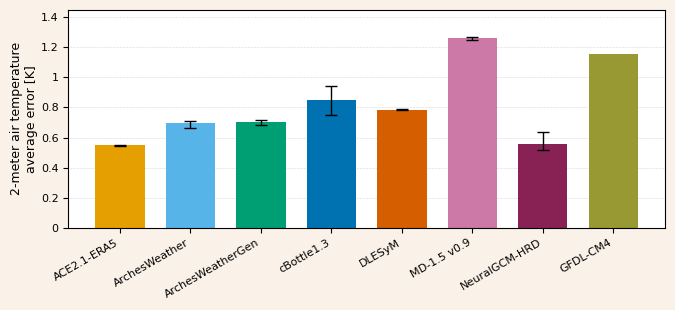

In [11]:
# Appendix Figure: standalone tas RMSB bar (training period only) — advertising/outreach version

LABEL_FS = 9

# Select training period only (first time_period index)
da = rmsb_1deg['tas'].isel(time_period=0)
print('Time period shown:', str(rmsb_1deg['tas'].time_period.values[0]))

lowest = da.min('realization')
median = da.median('realization')
highest = da.max('realization')
n_real = da.count('realization')

lower_err = np.where(n_real > 1, median.values - lowest.values, np.nan)
upper_err = np.where(n_real > 1, highest.values - median.values, np.nan)

models = list(da.experiment_submission.values)
x = np.arange(len(models))

fig, ax = plt.subplots(figsize=(GMD_DOUBLE_COL_IN, 3.2))

ax.bar(
    x, median.values, width=0.7, color=CATEGORICAL_COLORS,
    yerr=np.array([lower_err, upper_err]),
    capsize=4, error_kw=dict(elinewidth=1.0, ecolor='k', capthick=1.0),
)

ax.set_ylim([0, median.values.max() * 1.15])
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=LABEL_FS - 1)
ax.set_ylabel('2-meter air temperature\naverage error [K]', fontsize=LABEL_FS, labelpad=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}'))
ax.tick_params(axis='y', labelsize=LABEL_FS - 1)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle=':', linewidth=0.4, color='gray', alpha=0.6)

fig.patch.set_facecolor('#faf2e9')
fig.tight_layout()
ms_savefig(fig, 'app_rmsb_tas_bar')
plt.show()


Saved ./figures/manuscript_figures/app_bias_2p8deg_map_tas_pr.eps


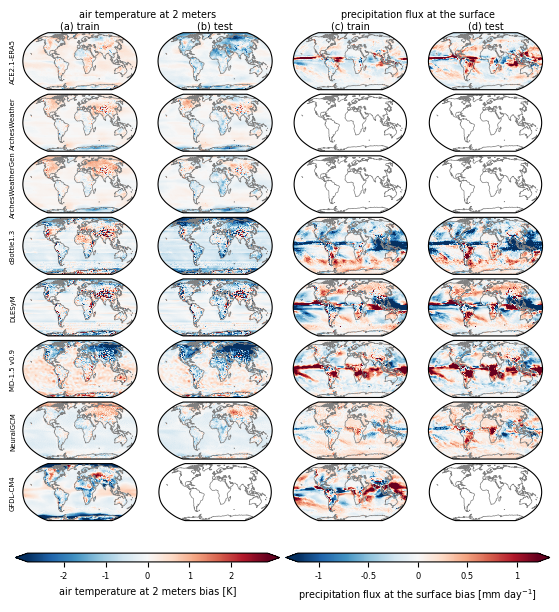

In [12]:
# Appendix Figure: tas and pr time-mean biases at 2.8° resolution (NeuralGCM included)
# Identical layout to the 1° manuscript bias map; data swapped to biases_2p8deg.

vars_to_plot = ['tas', 'pr']
time_periods  = ['training', 'test']
exp_names     = list(biases_2p8deg.experiment_submission.values)
n_exp         = len(exp_names)

LABEL_FS = 7

VAR_SCALE        = {'pr': 86400.}
VAR_DISPLAY_UNITS = {'pr': 'mm day$^{-1}$'}

cols   = [(var, tp) for var in vars_to_plot for tp in time_periods]
n_cols = len(cols)
n_rows = n_exp

vlims = {
    var: float(abs(biases_2p8deg[var].isel(realization=0).quantile(0.02))) * VAR_SCALE.get(var, 1.0)
    for var in vars_to_plot
}

map_h      = (GMD_DOUBLE_COL_IN / n_cols) / 1.9
fig_width  = GMD_DOUBLE_COL_IN
fig_height = min(n_rows * map_h * 1.15 + 1.0, GMD_MAX_HEIGHT_IN)

fig = plt.figure(figsize=(fig_width, fig_height))
gs  = fig.add_gridspec(nrows=n_rows, ncols=n_cols, hspace=0.08, wspace=0.05)
fig.subplots_adjust(top=0.92, left=0.12)

ims_by_var   = {}
axes_by_var  = {var: [] for var in vars_to_plot}
top_row_axes = {}
col0_axes    = {}

for row, exp in enumerate(exp_names):
    for col, (var, tp) in enumerate(cols):
        scale = VAR_SCALE.get(var, 1.0)
        ax = fig.add_subplot(gs[row, col], projection=ccrs.Robinson())
        axes_by_var[var].append(ax)
        if row == 0:
            top_row_axes[col] = ax
        if col == 0:
            col0_axes[row] = ax

        data = (biases_2p8deg[var].isel(realization=0)
                .sel(time_period=tp, experiment_submission=exp) * scale)

        if bool(np.isnan(data.values).all()):
            ax.set_global()
        else:
            im = data.plot(
                ax=ax,
                transform=ccrs.PlateCarree(),
                cmap='RdBu_r',
                vmin=-vlims[var], vmax=vlims[var],
                add_colorbar=False,
                add_labels=False, rasterized=True,
            )
            ims_by_var[var] = im

        ax.set_title('')
        ax.coastlines(color='gray', linewidth=0.5)

        if row == 0:
            period_label = 'train' if tp == 'training' else 'test'
            letter = chr(ord('a') + col)
            ax.set_title(f'({letter}) {period_label}', fontsize=LABEL_FS, pad=3)

for var in vars_to_plot:
    if var not in ims_by_var:
        continue
    units     = VAR_DISPLAY_UNITS.get(var, biases_2p8deg[var].attrs.get('units', '-'))
    long_name = biases_2p8deg[var].attrs.get('long_name', var).replace('_', ' ').lower()
    cbar = fig.colorbar(
        ims_by_var[var],
        ax=axes_by_var[var],
        orientation='horizontal',
        fraction=0.04,
        pad=0.06,
        aspect=30,
        extend='both',
    )
    cbar.set_label(f'{long_name} bias [{units}]', size=LABEL_FS)
    cbar.ax.tick_params(labelsize=LABEL_FS - 1)
    cbar.ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))

fig.canvas.draw()

pos_r0 = col0_axes[0].get_position()
pos_r1 = col0_axes[1].get_position()
renderer = fig.canvas.get_renderer()
longest_name = max(exp_names, key=len)
row_pitch_px = (pos_r0.y0 - pos_r1.y0) * fig.get_size_inches()[1] * renderer.dpi

row_label_fs = 4
for candidate_fs in range(LABEL_FS + 2, 3, -1):
    t = col0_axes[0].text(0, -1, longest_name, fontsize=candidate_fs,
                           transform=col0_axes[0].transAxes)
    fig.canvas.draw()
    bb = t.get_window_extent(renderer=renderer)
    t.remove()
    if bb.width <= row_pitch_px * 1.15:
        row_label_fs = candidate_fs
        break

for row, exp in enumerate(exp_names):
    col0_axes[row].text(-0.06, 0.5, exp,
                        transform=col0_axes[row].transAxes,
                        rotation=90, va='center', ha='right',
                        fontsize=row_label_fs, clip_on=False)

for vi, var in enumerate(vars_to_plot):
    pos_l = top_row_axes[vi * 2].get_position()
    pos_r = top_row_axes[vi * 2 + 1].get_position()
    x_center = (pos_l.x0 + pos_r.x1) / 2
    long_name = biases_2p8deg[var].attrs.get('long_name', var).replace('_', ' ').lower()
    fig.text(x_center, pos_l.y1 + 0.02, long_name,
             ha='center', va='bottom', fontsize=LABEL_FS)

fig.patch.set_alpha(0.0)
ms_savefig(fig, 'app_bias_2p8deg_map_tas_pr')
plt.show()


Saved ./figures/manuscript_figures/app_bias_1deg_map_train_tas.eps


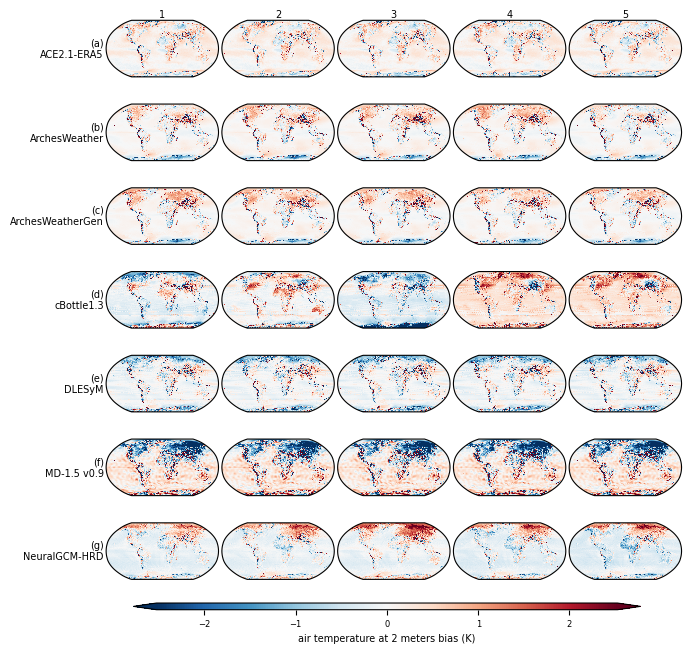

In [13]:
# Appendix Figure: 1° bias maps — tas, training period, all models × all realizations
# Rows = models, columns = realizations (r1–r5)

var        = 'tas'
tp         = 'training'
scale      = VAR_SCALE.get(var, 1.0)
exp_names  = [e for e in biases_1deg.experiment_submission.values if e not in ('GFDL-CM4', 'NeuralGCM')]
n_exp      = len(exp_names)
n_real_max = 5
row_letters = 'abcdefghijklmnopqrstuvwxyz'

vlim = float(abs(biases_1deg[var].sel(time_period=tp).quantile(0.02))) * scale

fig_width  = GMD_DOUBLE_COL_IN
fig_height = GMD_MAX_HEIGHT_IN

fig = plt.figure(figsize=(fig_width, fig_height))
gs  = fig.add_gridspec(nrows=n_exp, ncols=n_real_max, hspace=0.05, wspace=0.03)
fig.subplots_adjust(top=0.96, left=0.14, bottom=0.09, right=0.98)

last_im = None

for row, exp in enumerate(exp_names):
    da_exp  = biases_1deg[var].sel(experiment_submission=exp, time_period=tp) * scale
    row_ax = None

    for col in range(n_real_max):
        real_num = col + 1
        data     = da_exp.sel(realization=real_num)
        has_data = not bool(data.isnull().all())

        if has_data:
            ax = fig.add_subplot(gs[row, col], projection=ccrs.Robinson())
            if row_ax is None:
                row_ax = ax
            last_im = data.plot(
                ax=ax,
                transform=ccrs.PlateCarree(),
                cmap='RdBu_r',
                vmin=-vlim, vmax=vlim,
                add_colorbar=False,
                add_labels=False, rasterized=True,
            )
        else:
            ax = fig.add_subplot(gs[row, col])
            ax.set_visible(False)

        if row == 0:
            ax.set_title(f'{real_num}', fontsize=LABEL_FS, pad=2)

    # Two-line label: letter then name, right-aligned left of first panel
    row_ax.text(-0.02, 0.5, f'({row_letters[row]})\n{exp}', transform=row_ax.transAxes,
                fontsize=LABEL_FS, ha='right', va='center', linespacing=1.2)

# Single horizontal colorbar below grid
long_name = biases_1deg[var].attrs.get('long_name', var).lower()
units_str = biases_1deg[var].attrs.get('units', '')
cbar_ax = fig.add_axes([0.18, 0.062, 0.74, 0.010])
cbar    = fig.colorbar(last_im, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label(f'{long_name} bias ({units_str})', fontsize=LABEL_FS)
cbar.ax.tick_params(labelsize=LABEL_FS - 1)

ms_savefig(fig, 'app_bias_1deg_map_train_tas')


Saved ./figures/manuscript_figures/app_bias_1deg_map_test_tas.eps


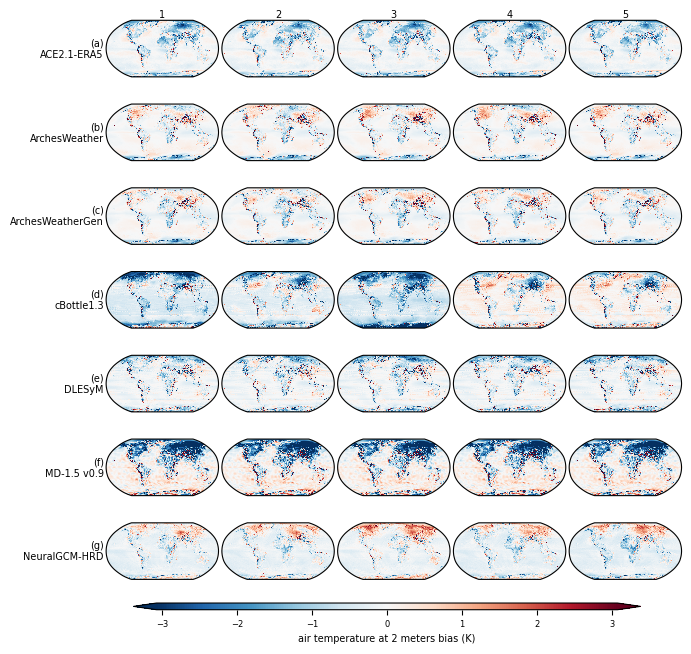

In [14]:
# Appendix Figure: 1° bias maps — tas, training period, all models × all realizations
# Rows = models, columns = realizations (r1–r5)

var        = 'tas'
tp         = 'test'
scale      = VAR_SCALE.get(var, 1.0)
exp_names  = [e for e in biases_1deg.experiment_submission.values if e not in ('GFDL-CM4', 'NeuralGCM')]
n_exp      = len(exp_names)
n_real_max = 5
row_letters = 'abcdefghijklmnopqrstuvwxyz'

vlim = float(abs(biases_1deg[var].sel(time_period=tp).quantile(0.02))) * scale

fig_width  = GMD_DOUBLE_COL_IN
fig_height = GMD_MAX_HEIGHT_IN

fig = plt.figure(figsize=(fig_width, fig_height))
gs  = fig.add_gridspec(nrows=n_exp, ncols=n_real_max, hspace=0.05, wspace=0.03)
fig.subplots_adjust(top=0.96, left=0.14, bottom=0.09, right=0.98)

last_im = None

for row, exp in enumerate(exp_names):
    da_exp  = biases_1deg[var].sel(experiment_submission=exp, time_period=tp) * scale
    row_ax = None

    for col in range(n_real_max):
        real_num = col + 1
        data     = da_exp.sel(realization=real_num)
        has_data = not bool(data.isnull().all())

        if has_data:
            ax = fig.add_subplot(gs[row, col], projection=ccrs.Robinson())
            if row_ax is None:
                row_ax = ax
            last_im = data.plot(
                ax=ax,
                transform=ccrs.PlateCarree(),
                cmap='RdBu_r',
                vmin=-vlim, vmax=vlim,
                add_colorbar=False,
                add_labels=False, rasterized=True,
            )
        else:
            ax = fig.add_subplot(gs[row, col])
            ax.set_visible(False)

        if row == 0:
            ax.set_title(f'{real_num}', fontsize=LABEL_FS, pad=2)

    # Two-line label: letter then name, right-aligned left of first panel
    row_ax.text(-0.02, 0.5, f'({row_letters[row]})\n{exp}', transform=row_ax.transAxes,
                fontsize=LABEL_FS, ha='right', va='center', linespacing=1.2)

# Single horizontal colorbar below grid
long_name = biases_1deg[var].attrs.get('long_name', var).lower()
units_str = biases_1deg[var].attrs.get('units', '')
cbar_ax = fig.add_axes([0.18, 0.062, 0.74, 0.010])
cbar    = fig.colorbar(last_im, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label(f'{long_name} bias ({units_str})', fontsize=LABEL_FS)
cbar.ax.tick_params(labelsize=LABEL_FS - 1)

ms_savefig(fig, 'app_bias_1deg_map_test_tas')


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved ./figures/manuscript_figures/app_rmsb_2p8deg_bar_surface_and_plev.eps


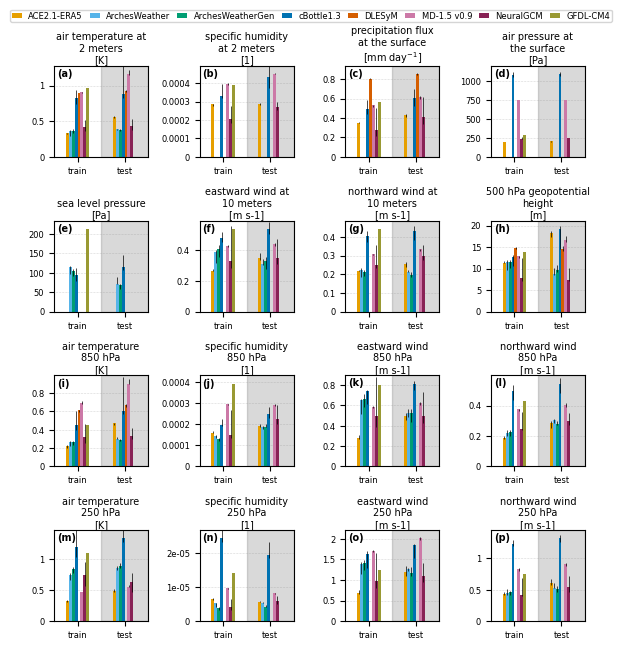

In [15]:
# Appendix Figure: RMSB bar chart at 2.8° resolution (NeuralGCM included)
# Identical layout to the 1° manuscript RMSB bar; data swapped to rmsb_2p8deg.

LABEL_FS = 7

VAR_SCALE = {
    'pr': 86400.,
}
VAR_DISPLAY_UNITS = {
    'pr': 'mm day$^{-1}$',
}

GRID = [
    [('tas', None),  ('huss', None), ('pr', None),   ('ps', None)  ],
    [('psl', None),  ('uas', None),  ('vas', None),  ('zg', None)  ],
    [('ta', 85000.), ('hus', 85000.),('ua', 85000.), ('va', 85000.)],
    [('ta', 25000.), ('hus', 25000.),('ua', 25000.), ('va', 25000.)],
]
NROWS, NCOLS = len(GRID), len(GRID[0])

fig_width  = GMD_DOUBLE_COL_IN
fig_height = min(NROWS * 1.8 + 0.4, GMD_MAX_HEIGHT_IN)
fig, axes  = plt.subplots(
    nrows=NROWS, ncols=NCOLS,
    figsize=(fig_width, fig_height),
    gridspec_kw={'wspace': 0.55, 'hspace': 0.7},
)
fig.subplots_adjust(top=0.90, bottom=0.07)

legend_handles = None
panel_letter = ord('a')

_tick_fmt = mticker.FuncFormatter(lambda x, _: f'{x:g}')

for r, row in enumerate(GRID):
    for c, spec in enumerate(row):
        ax = axes[r, c]

        if spec is None:
            ax.set_axis_off()
            continue

        letter = chr(panel_letter)
        panel_letter += 1

        varname, plev = spec

        if varname not in rmsb_2p8deg:
            ax.set_axis_off()
            ax.text(0.5, 0.5, f'{varname}\nnot available',
                    transform=ax.transAxes, ha='center', va='center', fontsize=LABEL_FS - 1)
            continue

        if plev is not None:
            da = rmsb_2p8deg[varname].sel(plev=plev).drop_vars('plev')
        else:
            da = rmsb_2p8deg[varname]

        da = da.transpose('time_period', 'experiment_submission', 'realization')

        scale = VAR_SCALE.get(varname, 1.0)
        units = VAR_DISPLAY_UNITS.get(varname, rmsb_2p8deg[varname].attrs.get('units', '-'))
        lowest  = da.min('realization').to_dataframe().unstack() * scale
        median  = da.median('realization').to_dataframe().unstack() * scale
        highest = da.max('realization').to_dataframe().unstack() * scale

        bars = median.plot.bar(
            ax=ax,
            legend=False,
            color=CATEGORICAL_COLORS,
            yerr=np.concat(
                [(median - lowest).values.T[:, None, :],
                 (highest - median).values.T[:, None, :]],
                axis=1,
            ),
            capsize=0,
            error_kw=dict(elinewidth=0.5),
        )
        if legend_handles is None:
            legend_handles, _ = ax.get_legend_handles_labels()

        ymax = median.max().max()
        ax.set_ylim([0, ymax * 1.1])
        xlim, ylim = ax.get_xlim(), ax.get_ylim()
        mid = (xlim[0] + xlim[1]) / 2
        ax.fill_between(
            [mid, xlim[1]], [0, 0], [ylim[1], ylim[1]],
            color='k', alpha=0.15, zorder=-1,
        )
        ax.set_xticklabels(['train', 'test'], rotation=0, fontsize=LABEL_FS - 1)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.yaxis.set_major_formatter(_tick_fmt)
        ax.tick_params(axis='y', labelsize=LABEL_FS - 1)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle=':', linewidth=0.4, color='gray', alpha=0.6)

        ax.text(0.03, 0.97, f'({letter})', transform=ax.transAxes,
                fontsize=LABEL_FS, fontweight='bold', va='top', ha='left', zorder=5)

        long_name = rmsb_2p8deg[varname].attrs.get('long_name', varname).replace('_', ' ').lower()
        if varname == 'zg':
            long_name = textwrap.fill(f'500 hPa {long_name}', width=22)
        else:
            long_name = textwrap.fill(long_name, width=18)
        if plev is not None:
            plev_hpa = int(plev / 100)
            title = f'{long_name}\n{plev_hpa} hPa\n[{units}]'
        else:
            title = f'{long_name}\n[{units}]'
        ax.set_title(title, fontsize=LABEL_FS, pad=2)

fig.legend(
    legend_handles,
    list(rmsb_2p8deg.experiment_submission.values),
    fontsize=LABEL_FS - 1,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=len(rmsb_2p8deg.experiment_submission),
    frameon=True,
    borderpad=0.2,
    columnspacing=0.8,
    handlelength=1.2,
)

fig.patch.set_alpha(0.0)
ms_savefig(fig, 'app_rmsb_2p8deg_bar_surface_and_plev')
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved ./figures/manuscript_figures/app_rmsb_1deg_plev_ta.eps


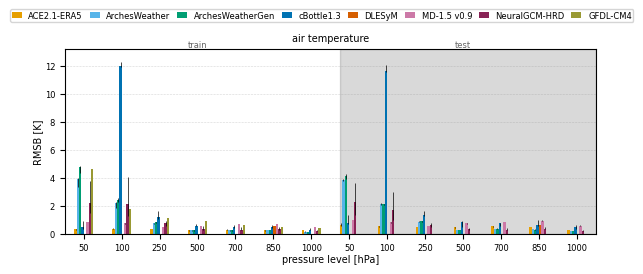

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved ./figures/manuscript_figures/app_rmsb_1deg_plev_hus.eps


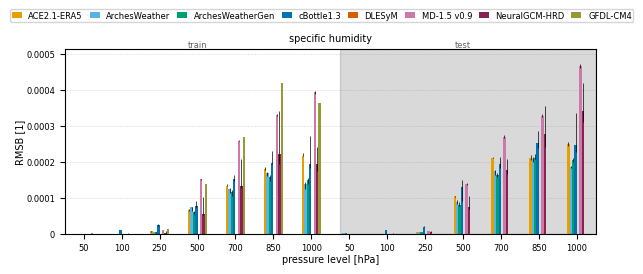

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved ./figures/manuscript_figures/app_rmsb_1deg_plev_ua.eps


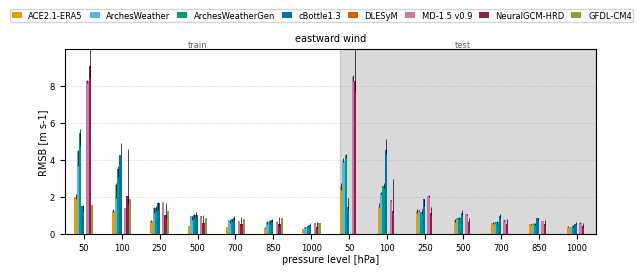

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved ./figures/manuscript_figures/app_rmsb_1deg_plev_va.eps


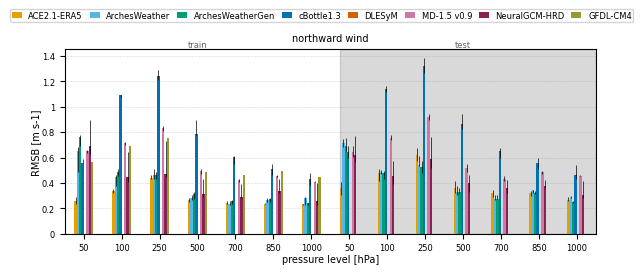

In [16]:
# Appendix Figures: GMD-styled pressure-level RMSB profiles for ta, hus, ua, va (1° data)
# One figure per variable — same data as the exploratory pressure-level cells above,
# but styled to manuscript conventions (LABEL_FS=7, ms_savefig, FuncFormatter).

LABEL_FS = 7

VAR_SCALE = {'pr': 86400.}
VAR_DISPLAY_UNITS = {'pr': 'mm day$^{-1}$'}

_tick_fmt = mticker.FuncFormatter(lambda x, _: f'{x:g}')

for varname in ['ta', 'hus', 'ua', 'va']:
    if varname not in rmsb_1deg or 'plev' not in rmsb_1deg[varname].dims:
        continue

    da = rmsb_1deg[varname].rename('RMSB').transpose(
        'time_period', 'plev', 'experiment_submission', 'realization'
    )
    scale = VAR_SCALE.get(varname, 1.0)
    units = VAR_DISPLAY_UNITS.get(varname, rmsb_1deg[varname].attrs.get('units', '-'))
    long_name = rmsb_1deg[varname].attrs.get('long_name', varname).replace('_', ' ').lower()

    lowest  = da.min('realization').to_dataframe().unstack() * scale
    median  = da.median('realization').to_dataframe().unstack() * scale
    highest = da.max('realization').to_dataframe().unstack() * scale

    fig, ax = plt.subplots(figsize=(GMD_DOUBLE_COL_IN, 2.6))

    bars = median.plot.bar(
        ax=ax,
        legend=False,
        color=CATEGORICAL_COLORS,
        yerr=np.concat(
            [(median - lowest).values.T[:, None, :],
             (highest - median).values.T[:, None, :]],
            axis=1,
        ),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    legend_handles, _ = ax.get_legend_handles_labels()

    ymax = median.max().max()
    ax.set_ylim([0, ymax * 1.1])
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    ax.fill_between(
        [xlim[1] / 2, xlim[1]], [0, 0], [ylim[1], ylim[1]],
        color='k', alpha=0.15, zorder=-1,
    )

    # X-tick labels: pressure level (hPa) for each group
    ax.set_xticklabels(
        [str(round(ind[1] / 100)) for ind in median.index],
        rotation=0, fontsize=LABEL_FS - 1,
    )
    ax.set_xlabel('pressure level [hPa]', fontsize=LABEL_FS, labelpad=1)
    ax.set_ylabel(f'RMSB [{units}]', fontsize=LABEL_FS, labelpad=1)
    ax.yaxis.set_major_formatter(_tick_fmt)
    ax.tick_params(axis='y', labelsize=LABEL_FS - 1)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=':', linewidth=0.4, color='gray', alpha=0.6)
    ax.set_title(textwrap.fill(long_name, width=50), fontsize=LABEL_FS)

    # Train / test region labels
    mid_x = (xlim[0] + xlim[1]) / 2
    ax.text((xlim[0] + mid_x) / 2, ylim[1], 'train',
            ha='center', va='bottom', fontsize=LABEL_FS - 1, color='0.4')
    ax.text((mid_x + xlim[1]) / 2, ylim[1], 'test',
            ha='center', va='bottom', fontsize=LABEL_FS - 1, color='0.4')

    fig.legend(
        legend_handles,
        list(rmsb_1deg.experiment_submission.values),
        fontsize=LABEL_FS - 1,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.99),
        ncol=len(rmsb_1deg.experiment_submission),
        frameon=True,
        borderpad=0.2,
        columnspacing=0.8,
        handlelength=1.2,
    )

    fig.patch.set_alpha(0.0)
    fig.subplots_adjust(top=0.82)
    ms_savefig(fig, f'app_rmsb_1deg_plev_{varname}')
    plt.show()
